<a href="https://colab.research.google.com/github/edumabagraham/understanding_mthars/blob/main/SKNet_HAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/edumabagraham/understanding_mthars/blob/main/SKNet_HAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The SK network for sensor-based HAR

A PyTorch implementation of the selective kernel network from:

> W. Gao, L. Zhang, W. Huang, F. Min, J. He and A. Song, "Deep Neural Networks for
> Sensor-Based Human Activity Recognition Using Selective Kernel Convolution,"
> *IEEE Transactions on Instrumentation and Measurement*, vol. 70, 2021.

This is the backbone that MTHARS builds on:

> J. Duan et al., "A Multi-Task Deep Learning Approach for Sensor-based Human
> Activity Recognition and Segmentation," 2023. (Sec. III-C: "The MTHARS approach
> consists of the SK network [44] as a backbone network, the Windows Generate
> module and the recognition and segmentation module.")

The point of the architecture is an **adaptive temporal receptive field**. Each
SK convolution runs several branches with different receptive fields over the
time axis and uses softmax attention to weight them per channel, so the network
can prefer a short RF for a brief activity like "jumping" and a long one for a
sustained activity like "jogging" (Gao Fig. 6).

Everything here is 1-D along time. There is no image-classification variant of
this design: the branch RFs of 3, 5 and 7 timesteps are the whole idea.

## Architecture

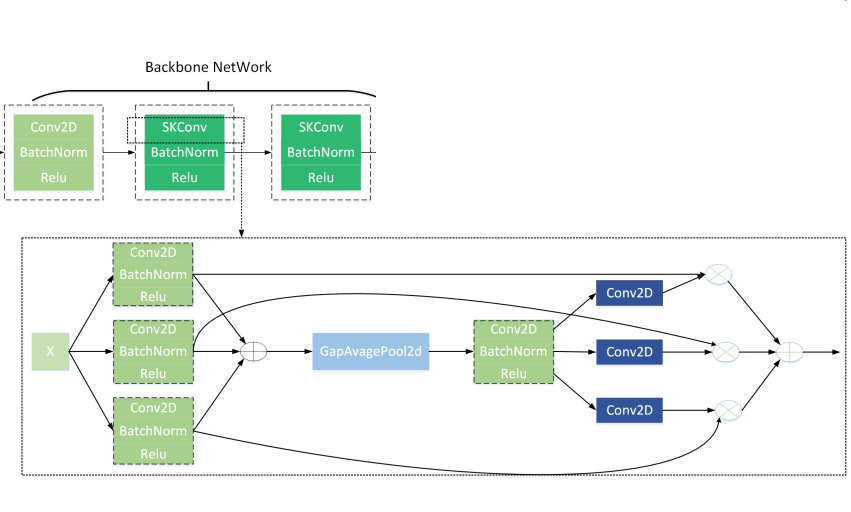

Gao Fig. 1. `Conv64 - SKConv128 - SKConv256 - FC - Softmax` (Sec. III-B).

The exact layer parameters are given in MTHARS Table I:

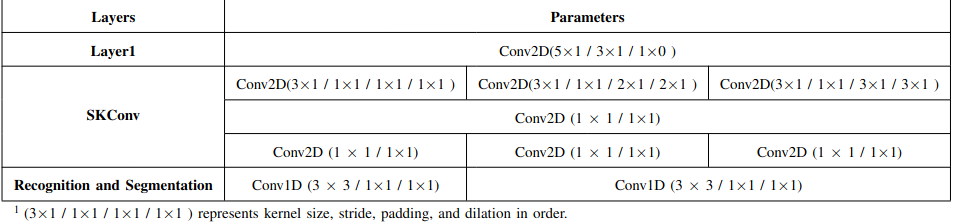

| Layer | kernel / stride / padding / dilation |
|---|---|
| Layer1 | `5x1 / 3x1 / 1x0` |
| SKConv branch 1 | `3x1 / 1x1 / 1x1 / 1x1` |
| SKConv branch 2 | `3x1 / 1x1 / 2x1 / 2x1` |
| SKConv branch 3 | `3x1 / 1x1 / 3x1 / 3x1` |
| Fuse | `Conv2D(1x1 / 1x1)` |
| Select | `Conv2D(1x1 / 1x1)` per branch |

Two notes on reading this table.

**Kernels are `Nx1`, never `NxN`.** Only the time axis is convolved and dilated.
The sensor axis has no spatial adjacency to exploit -- accelerometer-x sitting
next to gyroscope-z in the tensor is an arbitrary ordering choice -- so a kernel
that spans it would be mixing unrelated signals, and the branch receptive fields
would no longer be the 3 / 5 / 7 timesteps the paper's attention analysis rests on.

**The `1x1` padding on the branches looks like a typo.** With a kernel width of 1,
padding the width by 1 grows the sensor axis by 2 at every layer. Padding is
`(D, 0)` below: it keeps the temporal length fixed, which is what the SK layers
are supposed to do.

Tensor layout used throughout: **`(B, C, T, S)`** -- time on the height axis,
sensor channels on the width axis. This is the layout that makes MTHARS's "length
of the feature sequence" well defined, since Layer1's stride of 3 is the only
temporal downsampling in the backbone.

In [1]:
# Import PyTorch
import torch
from torch import nn

# Import matplotlib for visualization
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
print(f"Device: {device}")

PyTorch version: 2.11.0+cu128
Device: cuda


# 1. Data: UCI-HAR

30 subjects wearing a waist-mounted smartphone, 6 activities, 9 inertial channels
(body acceleration, body gyroscope and total acceleration, each x/y/z) sampled at
50 Hz. The dataset ships pre-windowed at **128 timesteps with 50% overlap**, which
is the window length Gao et al. use (Table I), and with the standard
subject-disjoint train/test split.

Each sample is therefore `(1, 128, 9)` -> `(C, T, S)`.

In [2]:
import zipfile
from pathlib import Path
import requests

DATA_DIR = Path("data")
UCI_ROOT = DATA_DIR / "UCI HAR Dataset"
URL = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"
# Alternative mirror if the above is unavailable:
# https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip

if UCI_ROOT.is_dir():
  print(f"{UCI_ROOT} already exists, skipping download")
else:
  DATA_DIR.mkdir(parents=True, exist_ok=True)
  archive = DATA_DIR / "uci_har.zip"

  print("Downloading UCI-HAR...")
  response = requests.get(URL, timeout=120)
  response.raise_for_status()
  archive.write_bytes(response.content)

  with zipfile.ZipFile(archive) as z:
    z.extractall(DATA_DIR)

  # The UCI download wraps the dataset in a second zip.
  for nested in DATA_DIR.glob("*.zip"):
    if nested == archive:
      continue
    with zipfile.ZipFile(nested) as z:
      z.extractall(DATA_DIR)

  print(f"Extracted to {UCI_ROOT}")

print(sorted(p.name for p in UCI_ROOT.iterdir()))

Extracted to data/UCI HAR Dataset
['.DS_Store', 'README.txt', 'activity_labels.txt', 'features.txt', 'features_info.txt', 'test', 'train']


In [3]:
import numpy as np

# body_acc, body_gyro and total_acc, x/y/z each -> 9 sensor channels.
SIGNALS = [f"{signal}_{axis}" for signal in ("body_acc", "body_gyro", "total_acc")
                              for axis in ("x", "y", "z")]

ACTIVITIES = ["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS",
              "SITTING", "STANDING", "LAYING"]

def load_split(split: str):
  """Load one UCI-HAR split as (X, y) with X of shape (N, 1, 128, 9)."""
  signal_dir = UCI_ROOT / split / "Inertial Signals"

  # Each file is (N, 128); stacking on the last axis gives (N, 128, 9) = (N, T, S).
  channels = [np.loadtxt(signal_dir / f"{name}_{split}.txt") for name in SIGNALS]
  X = np.stack(channels, axis=-1)

  y = np.loadtxt(UCI_ROOT / split / f"y_{split}.txt").astype(int) - 1 # 1..6 -> 0..5

  X = torch.from_numpy(X).float().unsqueeze(1) # (N, 1, T, S)
  return X, torch.from_numpy(y).long()

X_train, y_train = load_split("train")
X_test, y_test = load_split("test")

# Zero mean / unit variance per sensor channel (Gao et al., Sec. IV), using the
# training statistics only so no test information leaks into the normalization.
mean = X_train.mean(dim=(0, 2), keepdim=True)
std = X_train.std(dim=(0, 2), keepdim=True)
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

class_names = ACTIVITIES
print(f"Train: {tuple(X_train.shape)}  labels {tuple(y_train.shape)}")
print(f"Test:  {tuple(X_test.shape)}  labels {tuple(y_test.shape)}")
print(f"Classes: {class_names}")
print(f"Class counts (train): {torch.bincount(y_train).tolist()}")

Train: (7352, 1, 128, 9)  labels (7352,)
Test:  (2947, 1, 128, 9)  labels (2947,)
Classes: ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']
Class counts (train): [1226, 1073, 986, 1286, 1374, 1407]


In [4]:
from torch.utils.data import DataLoader, TensorDataset

BATCH_SIZE = 64

train_dataloader = DataLoader(TensorDataset(X_train, y_train),
                              batch_size=BATCH_SIZE,
                              shuffle=True)

test_dataloader = DataLoader(TensorDataset(X_test, y_test),
                             batch_size=BATCH_SIZE,
                             shuffle=False)

print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

X_batch, y_batch = next(iter(train_dataloader))
print(f"Batch shape: {tuple(X_batch.shape)} -> (batch, channel, time, sensor)")

Length of train dataloader: 115 batches of 64
Length of test dataloader: 47 batches of 64
Batch shape: (64, 1, 128, 9) -> (batch, channel, time, sensor)


# 2. Model

## 2.1 SKUnit

The transformation used inside each branch. Sec. III-A-1: "the three
transformations F1, F2 and F3 consist of grouped convolutions, batch
normalization and ReLU activation in sequence."

In [5]:
class SKUnit(nn.Module):
  """conv -> BN -> ReLU, the transformation used inside each SK branch."""
  def __init__(self, in_channels: int, out_channels: int,
               kernel_size: tuple, stride: tuple, padding: tuple, dilation: tuple,
               groups: int = 1):
    super().__init__()

    self.block_1 = nn.Sequential(
        nn.Conv2d(in_channels=in_channels,
                 out_channels=out_channels,
                 kernel_size=kernel_size,
                 stride=stride,
                 padding=padding,
                 dilation=dilation,
                 groups=groups,   # group number G, Sec. III-A-1 (best: G=32, Table IV)
                 bias=False),     # the bias is cancelled by the BN that follows
        nn.BatchNorm2d(num_features=out_channels),
        nn.ReLU(inplace=True)
    )

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    x = self.block_1(x)
    return x

## 2.2 SKConv

The selective kernel convolution itself: **Split**, **Fuse**, **Select**
(Sec. III-A, Eqs. 1-8).

- **Split** (Sec. III-A-1) -- `M` branches with different temporal receptive
  fields. A `3x1` kernel with dilation `D` has the same RF as a `(2D+1)x1` kernel
  at a third of the parameters, so dilation 1/2/3 gives the 3x1 / 5x1 / 7x1 RFs.
  Table IV confirms the dilated form is both cheaper and slightly more accurate.
- **Fuse** (Eqs. 1-4) -- sum the branches, global average pool to per-channel
  statistics `m`, compress to `n` with `d = C / r`.
- **Select** (Eqs. 5-8) -- one attention vector per branch, softmax **across
  branches** so the weights sum to 1 per channel, then a weighted sum of the
  branch outputs.

Defaults are the paper's ablation optima: `M=3` (Table V -- `M=4` is marginally
better but `M=3` is the recommended accuracy/cost balance), `G=32` (Table IV),
`r=32` (Table VI).

In [6]:
class SKConv(nn.Module):
  """Selective kernel convolution: Split / Fuse / Select (Gao et al., Sec. III-A).

  Args:
      M: branch number. Branch i uses a 3x1 kernel with dilation i, giving the
         effective kernel sizes 3x1, 5x1, 7x1, ... (Sec. III-A-1).
      G: group number of the grouped convolutions (Table IV: G=32 is best).
      r: reduction ratio, d = C / r (Eq. 4; Table VI: r=32 is best).
  """
  def __init__(self, in_channels: int, out_channels: int,
               M: int = 3, G: int = 32, r: int = 32):
    super().__init__()

    if in_channels % G or out_channels % G:
      raise ValueError(f"grouped convolution needs in_channels ({in_channels}) and "
                       f"out_channels ({out_channels}) divisible by G ({G})")

    # ---- Split: M branches with different receptive fields along the time axis.
    self.branches = nn.ModuleList([
        SKUnit(in_channels, out_channels,
               kernel_size=(3, 1),
               stride=(1, 1),
               padding=(D, 0),      # keeps the temporal length unchanged
               dilation=(D, 1),     # dilate the TIME axis only
               groups=G)
        for D in range(1, M + 1)
    ])

    # ---- Fuse: global average pooling (Eq. 2) then an FC layer (Eq. 3).
    self.gap = nn.AdaptiveAvgPool2d(1)

    d = max(out_channels // r, 1)          # Eq. (4): d = C / r
    self.bottleneck = nn.Sequential(       # Eq. (3): n = ReLU(BN(W m))
        nn.Conv2d(out_channels, d, kernel_size=1, bias=False),  # 1x1 conv on a 1x1
        nn.BatchNorm2d(d),                                      # map == an FC layer
        nn.ReLU(inplace=True),
    )

    # ---- Select: one attention matrix per branch, A, B, C in R^{Cxd} (Eqs. 5-7).
    self.attn = nn.ModuleList([
        nn.Conv2d(d, out_channels, kernel_size=1, stride=1) for _ in range(M)
    ])

  def forward(self, x: torch.Tensor, return_attention: bool = False):
    feas = torch.stack([branch(x) for branch in self.branches], dim=1)  # (B,M,C,T,S)

    F = feas.sum(dim=1)                                    # Eq. (1)
    m = self.gap(F)                                        # Eq. (2)  (B,C,1,1)
    n = self.bottleneck(m)                                 # Eq. (3)  (B,d,1,1)

    attn = torch.stack([a(n) for a in self.attn], dim=1)   # (B,M,C,1,1)
    attn = torch.softmax(attn, dim=1)                      # Eqs. (5)-(7): a+b+c = 1

    out = (feas * attn).sum(dim=1)                         # Eq. (8)  (B,C,T,S)

    if return_attention:
      # (B, M, C): the per-branch weights, for reproducing the analysis in Fig. 6.
      return out, attn.flatten(start_dim=3).squeeze(-1)
    return out

## 2.3 SKNet

`Conv64 - SKConv128 - SKConv256 - FC - Softmax` (Sec. III-B).

Nothing sits between the SK layers: each branch already ends in BN+ReLU inside
`SKUnit`, and the fused output (Eq. 8) is a convex combination of those
non-negative branch outputs, so an extra BN+ReLU wrapper around each `SKConv`
would be adding a layer the paper does not have.

`return_sequence=True` is what MTHARS needs. Its Windows Generate module places
`n x m x 2` anchor windows over a feature sequence of length `n`, so the backbone
must not collapse the time axis the way the classification head does.

In [7]:
class SKNet(nn.Module):
  """Conv64-SKConv128-SKConv256-FC-Softmax (Gao et al., Sec. III-B).

  Input layout: (B, C, T, S) -- time on the height axis, sensors on the width axis.

  Args:
      return_sequence: if True, return the backbone feature sequence (B, C, n)
          instead of class logits -- the input MTHARS's Windows Generate module
          expects.
  """
  def __init__(self, in_channels: int, ch1: int, ch2: int, ch3: int, num_classes: int,
               M: int = 3, G: int = 32, r: int = 32, return_sequence: bool = False):
    super().__init__()

    self.return_sequence = return_sequence

    # MTHARS Table I, Layer1: Conv2D(5x1 / 3x1 / 1x0).
    # The stride of 3 is the only temporal downsampling in the backbone; it sets
    # the length of the feature sequence MTHARS builds its windows on.
    # Not grouped: in_channels is 1, which is not divisible by G.
    self.layer_1 = SKUnit(
        in_channels=in_channels,
        out_channels=ch1,
        kernel_size=(5,1),
        stride=(3,1),
        padding=(1,0),
        dilation=(1,1),
        groups=1)

    self.layer_2 = SKConv(in_channels=ch1, out_channels=ch2, M=M, G=G, r=r)
    self.layer_3 = SKConv(in_channels=ch2, out_channels=ch3, M=M, G=G, r=r)

    self.classifier = nn.Sequential(
        nn.AdaptiveAvgPool2d(1),
        nn.Flatten(),
        nn.Linear(in_features=ch3,
                  out_features=num_classes)
    )

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    x = self.layer_1(x)
    x = self.layer_2(x)
    x = self.layer_3(x)
    if self.return_sequence:
      # Collapse the sensor axis only, keeping time: (B, C, n). Neither paper
      # states how the sensor axis is reduced before the MTHARS head; averaging
      # is the assumption made here.
      return x.mean(dim=3)
    x = self.classifier(x)
    return x

torch.manual_seed(42)
model = SKNet(in_channels=1,
              ch1=64,
              ch2=128,
              ch3=256,
              num_classes=len(class_names)).to(device)

model

SKNet(
  (layer_1): SKUnit(
    (block_1): Sequential(
      (0): Conv2d(1, 64, kernel_size=(5, 1), stride=(3, 1), padding=(1, 0), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
  )
  (layer_2): SKConv(
    (branches): ModuleList(
      (0): SKUnit(
        (block_1): Sequential(
          (0): Conv2d(64, 128, kernel_size=(3, 1), stride=(1, 1), padding=(1, 0), groups=32, bias=False)
          (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
      )
      (1): SKUnit(
        (block_1): Sequential(
          (0): Conv2d(64, 128, kernel_size=(3, 1), stride=(1, 1), padding=(2, 0), dilation=(2, 1), groups=32, bias=False)
          (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
      )
      (2): SKUnit(
        (block_1): Sequential(
    

## 2.4 Sanity checks

Worth confirming before training: the model is as small as the paper claims, and
the shapes are what MTHARS expects.

In [8]:
def count_params(m: nn.Module) -> int:
  return sum(p.numel() for p in m.parameters() if p.requires_grad)

print(f"SKNet parameters: {count_params(model):,}")

# Gao et al. claim the SK network's accuracy gain comes "at similar computational
# overhead" (Sec. I). Grouping (G=32) and 1-D dilated kernels are what pay for it:
# with square 3x3 kernels and no grouping the same network is ~1.1M parameters,
# ~40x larger, and any gain would just be capacity.

SKNet parameters: 27,230


In [9]:
torch.manual_seed(42)
har_batch = X_test[:4].to(device) # (4, 1, 128, 9)

backbone = SKNet(in_channels=1, ch1=64, ch2=128, ch3=256,
                 num_classes=len(class_names), return_sequence=True).to(device)

with torch.inference_mode():
  logits = model(har_batch)
  seq = backbone(har_batch)

print(f"Input:            {tuple(har_batch.shape)}")
print(f"Logits:           {tuple(logits.shape)}")
print(f"Feature sequence: {tuple(seq.shape)}  -> (B, C, n) for MTHARS")

# n = 42 comes from Layer1's stride of 3 over 128 timesteps:
# floor((128 + 2*1 - 5) / 3) + 1 = 41 + 1 = 42. The SK layers preserve it, since
# padding = dilation for a 3x1 kernel. MTHARS then generates n x m x 2 windows.

Input:            (4, 1, 128, 9)
Logits:           (4, 6)
Feature sequence: (4, 256, 42)  -> (B, C, n) for MTHARS


# 3. Training

Gao et al. train with Adam and an exponentially decaying learning rate (Sec. IV).
The per-dataset batch size and initial learning rate are in the paper's Table II;
the values below are reasonable defaults rather than that table's exact numbers,
so set them from the paper if you are reproducing precisely.

In [10]:
def accuracy_fn(y_true: torch.Tensor, y_pred: torch.Tensor) -> float:
  """Percentage of predictions in y_pred that match y_true."""
  correct = torch.eq(y_true, y_pred).sum().item()
  return (correct / len(y_pred)) * 100


def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):

  train_loss, train_acc = 0, 0
  model.to(device)
  model.train()
  for batch, (X, y) in enumerate(data_loader):
    X, y = X.to(device), y.to(device)

    # 1. Forward pass
    y_pred = model(X)

    # 2. Calculate loss and accuracy
    loss = loss_fn(y_pred, y)
    train_loss += loss.item() # .item() detaches from the graph; accumulating the
                              # tensor keeps every batch's autograd graph alive
    train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Backward propagation
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

  train_loss /= len(data_loader)
  train_acc /= len(data_loader)
  print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")
  return train_loss, train_acc


def test_step(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
  test_loss, test_acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for batch, (X, y) in enumerate(data_loader):
      X, y = X.to(device), y.to(device)

      test_pred = model(X)

      test_loss += loss_fn(test_pred, y).item()
      test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))

    test_loss /= len(data_loader)
    test_acc /= len(data_loader)
    print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")
  return test_loss, test_acc

In [11]:
from timeit import default_timer as timer
from tqdm.auto import tqdm

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.96)

torch.manual_seed(42)
EPOCHS = 50

history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
train_time_start = timer()

for epoch in tqdm(range(EPOCHS)):
  print(f"Epoch: {epoch}\n-------")
  train_loss, train_acc = train_step(model, train_dataloader, loss_fn, optimizer, accuracy_fn)
  test_loss, test_acc = test_step(model, test_dataloader, loss_fn, accuracy_fn)
  scheduler.step()

  history["train_loss"].append(train_loss)
  history["train_acc"].append(train_acc)
  history["test_loss"].append(test_loss)
  history["test_acc"].append(test_acc)

total_train_time = timer() - train_time_start
print(f"Train time on {device}: {total_train_time:.3f} seconds")

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 0
-------
Train loss: 0.93639 | Train accuracy: 70.97%
Test loss: 0.58121 | Test accuracy: 78.66%

Epoch: 1
-------
Train loss: 0.43406 | Train accuracy: 85.36%
Test loss: 0.63439 | Test accuracy: 72.01%

Epoch: 2
-------
Train loss: 0.34131 | Train accuracy: 87.09%
Test loss: 0.60410 | Test accuracy: 73.37%

Epoch: 3
-------
Train loss: 0.30708 | Train accuracy: 87.95%
Test loss: 0.38951 | Test accuracy: 83.61%

Epoch: 4
-------
Train loss: 0.27302 | Train accuracy: 89.31%
Test loss: 0.66933 | Test accuracy: 72.34%

Epoch: 5
-------
Train loss: 0.25828 | Train accuracy: 89.80%
Test loss: 0.34406 | Test accuracy: 86.14%

Epoch: 6
-------
Train loss: 0.23505 | Train accuracy: 90.70%
Test loss: 0.32000 | Test accuracy: 86.44%

Epoch: 7
-------
Train loss: 0.22004 | Train accuracy: 91.05%
Test loss: 0.45419 | Test accuracy: 82.45%

Epoch: 8
-------
Train loss: 0.20633 | Train accuracy: 91.46%
Test loss: 0.36980 | Test accuracy: 84.34%

Epoch: 9
-------
Train loss: 0.21119 | Train a

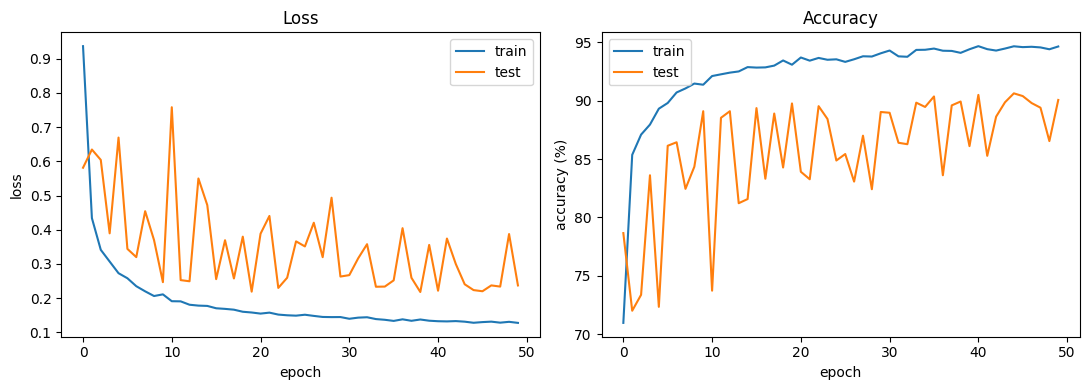

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(history["train_loss"], label="train")
ax1.plot(history["test_loss"], label="test")
ax1.set_xlabel("epoch"); ax1.set_ylabel("loss"); ax1.set_title("Loss"); ax1.legend()

ax2.plot(history["train_acc"], label="train")
ax2.plot(history["test_acc"], label="test")
ax2.set_xlabel("epoch"); ax2.set_ylabel("accuracy (%)"); ax2.set_title("Accuracy"); ax2.legend()

plt.tight_layout()

# 4. Evaluation

Overall accuracy plus a confusion matrix. Gao et al. (Fig. 9) use confusion
matrices to show where the adaptive RF helps -- the interesting cases are the
static postures (sitting vs standing), which are hard to separate from a single
fixed receptive field.

In [13]:
def evaluate(model: torch.nn.Module,
             data_loader: torch.utils.data.DataLoader,
             device: torch.device = device):
  """Return (predictions, targets) over the whole loader."""
  preds, targets = [], []
  model.eval()
  with torch.inference_mode():
    for X, y in tqdm(data_loader):
      X = X.to(device)
      preds.append(model(X).argmax(dim=1).cpu())
      targets.append(y)
  return torch.cat(preds), torch.cat(targets)


y_pred, y_true = evaluate(model, test_dataloader)

overall = accuracy_fn(y_true=y_true, y_pred=y_pred)
print(f"\nTest accuracy: {overall:.2f}%\n")

# Per-class accuracy
for i, name in enumerate(class_names):
  mask = y_true == i
  print(f"{name:<22} {accuracy_fn(y_true=y_true[mask], y_pred=y_pred[mask]):6.2f}%  (n={mask.sum().item()})")

  0%|          | 0/47 [00:00<?, ?it/s]


Test accuracy: 89.85%

WALKING                 96.98%  (n=496)
WALKING_UPSTAIRS        95.75%  (n=471)
WALKING_DOWNSTAIRS      98.10%  (n=420)
SITTING                 79.23%  (n=491)
STANDING                71.05%  (n=532)
LAYING                 100.00%  (n=537)


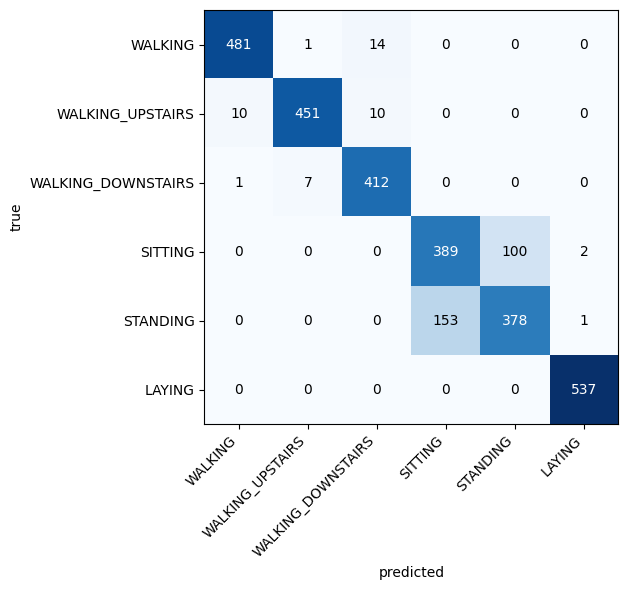

In [14]:
# Confusion matrix
num_classes = len(class_names)
cm = torch.zeros(num_classes, num_classes, dtype=torch.int64)
for t, p in zip(y_true, y_pred):
  cm[t, p] += 1

fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(num_classes), class_names, rotation=45, ha="right")
ax.set_yticks(range(num_classes), class_names)
ax.set_xlabel("predicted"); ax.set_ylabel("true")

threshold = cm.max() / 2
for i in range(num_classes):
  for j in range(num_classes):
    ax.text(j, i, cm[i, j].item(), ha="center", va="center",
            color="white" if cm[i, j] > threshold else "black")

plt.tight_layout()

# 5. Inspecting the kernel selection

The claim the architecture rests on is that the attention weights shift toward
larger receptive fields for longer-lasting activities (Gao Fig. 6). `SKConv`
returns its per-branch weights with `return_attention=True`, so that analysis can
be run directly: mean weight per branch, per activity class.

In [15]:
branch_rfs = ["3x1 (D=1)", "5x1 (D=2)", "7x1 (D=3)"]

model.eval()
weights_by_class = {name: [] for name in class_names}

with torch.inference_mode():
  for X, y in tqdm(test_dataloader):
    X = X.to(device)
    h = model.layer_1(X)
    h = model.layer_2(h)
    _, attn = model.layer_3(h, return_attention=True) # (B, M, C)
    attn = attn.mean(dim=2).cpu()                     # mean over channels -> (B, M)
    for name_idx, name in enumerate(class_names):
      mask = y == name_idx
      if mask.any():
        weights_by_class[name].append(attn[mask])

print(f"Mean attention weight per branch, SKConv256 (layer_3)\n")
print(f"{'activity':<22}" + "".join(f"{rf:>14}" for rf in branch_rfs))
for name, chunks in weights_by_class.items():
  mean_w = torch.cat(chunks).mean(dim=0)
  print(f"{name:<22}" + "".join(f"{w:>14.4f}" for w in mean_w))

  0%|          | 0/47 [00:00<?, ?it/s]

Mean attention weight per branch, SKConv256 (layer_3)

activity                   3x1 (D=1)     5x1 (D=2)     7x1 (D=3)
WALKING                       0.3597        0.3259        0.3144
WALKING_UPSTAIRS              0.3216        0.3086        0.3698
WALKING_DOWNSTAIRS            0.3526        0.3148        0.3327
SITTING                       0.3464        0.3232        0.3304
STANDING                      0.3206        0.3312        0.3482
LAYING                        0.3482        0.2960        0.3558


# 6. Using SKNet as the MTHARS backbone

MTHARS (Sec. III-C) stacks three pieces on top of this network: the SK backbone,
a Windows Generate module and a recognition-and-segmentation module. Only the
first is implemented here. What the next stage needs from this file is the
feature sequence:

```python
backbone = SKNet(in_channels=1, ch1=64, ch2=128, ch3=256,
                 num_classes=num_classes, return_sequence=True)
features = backbone(x)          # (B, 256, n)
```

With a 128-timestep window, `n = 42`. The Windows Generate module then centres
`m` windows of different scales on each of the `n` units (Duan Fig. 1), and the
recognition/segmentation module predicts, per window, a class over `k+1` labels
(class 0 = background) and two boundary offsets `(fx, fl)` -- both through
convolutions that preserve the sequence length, so output and input coordinates
stay aligned (Sec. III-D).

Losses are SmoothL1 on the offsets (Eq. 5) and cross-entropy on the classes
(Eq. 7), with hard negative mining over unmatched windows, then NMS at inference.